# Comparison with the analytical solution

The stem cells of a crypt are described as a ring of $N_s$ positions in which a
cell is replaced by one of its two neighbours at rate $\lambda$. The number of
labeled cells therefore performs a random walk with the absorbing boundaries
*extinction* ($P_0$) and *fixation* ($P_{N_s}$). The closed-form solution of
that walk is implemented in `analytical.py`, for equally likely replacement
directions and for a bias $\delta$ between them.

Each figure compares the analytical curves with the corresponding simulation:
the left panel shows the absolute extinction and fixation probability, the right
panel the clone size distribution conditioned on survival,
$P_{pers} = P_n / (1 - P_0)$, which is the quantity the experiment observes.

The notebook is part of the `scb2d_analysis` package and uses its modules. The
first cell adds the directory containing the package to `sys.path`, so that the
imports resolve independently of the directory the kernel is started in.

In [9]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# The notebook is located inside the package, therefore the directory
# *containing* `scb2d_analysis` has to be on the import path. It is located by
# walking up from the working directory.
for folder in [Path.cwd(), *Path.cwd().parents]:
    if (folder / "scb2d_analysis" / "__init__.py").exists():
        if str(folder) not in sys.path:
            sys.path.insert(0, str(folder))
        break

from scb2d_analysis import analytical, datasets, experimental_data, fixation
from scb2d_analysis import io_simulation, monoclonality
from scb2d_analysis.plot_style import COLORS, PAPER_RED, save_figure, setup_plot_style

plt.rcdefaults()

# Font of the panels, the same as in the other two notebooks. matplotlib reads
# these settings when a figure is created, so they are applied here rather than
# in the figure cells below.
plt.rcParams.update({"font.size": 9, "font.family": "Arial"})

# Export of the panels. Set to True to write every figure into FIGURE_DIR;
# `run_notebooks.py` turns it on through the environment.
SAVE_FIGURES = os.environ.get("SCB2D_SAVE_FIGURES") == "1"
FIGURE_DIR = Path(datasets.__file__).parent / "figures"

# Report configured but unreachable inputs before any analysis is run.
missing = datasets.analytical_comparison_missing_paths()
if missing:
    raise FileNotFoundError("configured but missing:\n  " + "\n  ".join(missing))

for run_name in datasets.ANALYTICAL_COMPARISON_RUNS:
    print(run_name)

WT, kr = 0, kd = 0.21
WT, p1 = 0.0525, p2 = 0.21
WT, LI 0-1, 0.0625 / 0.25
LI 0-1, 0.0625 / 0.25, mutant kd = 0.5
LI 0-1, 0.0625 / 0.25, mutant kd = 0.67
LI 0-1, 0.0625 / 0.25, mutant kd = 0.83


## Simulated curves

The two helpers below assemble the simulated counterparts of the analytical
quantities from the package functions. Reading a run folder is the
time-consuming step, so both results are cached per run and reused by the
figures.

In [10]:
# Last day evaluated on the simulated curves; longer than any period plotted
# below, so that the curves reach their plateau.
MAX_SIMULATED_DAY = 1000

_extinction_fixation_cache = {}
_persisting_cache = {}


def simulated_extinction_and_fixation(run_name, max_day=MAX_SIMULATED_DAY):
    """
    Mean cumulative extinction and fixation probability of one run.

    Parameters
    ----------
    run_name : str
        Key of `datasets.ANALYTICAL_COMPARISON_RUNS`.
    max_day : int
        Last day to be evaluated.

    Returns
    -------
    extinction, fixation : ndarray
        Mean probability per day, averaged over the simulation runs. Both curves
        are anchored at day 0 with probability 0, so that the index of the array
        is the simulation day.
    """
    if run_name in _extinction_fixation_cache:
        return _extinction_fixation_cache[run_name]

    events = io_simulation.read_fixation_events_from_directory(
        datasets.pos_and_time_folder(datasets.ANALYTICAL_COMPARISON_RUNS[run_name])
    )

    curves = []
    for group_events_by_day in (fixation.group_extinction_events_by_day,
                                fixation.group_fixation_events_by_day):
        events_by_day = group_events_by_day(events, max_day=max_day)
        cumulative_per_run = fixation.compute_cumulative_probability_per_run(events_by_day)
        _, means, _ = fixation.average_probability_curves(cumulative_per_run)
        curves.append(np.insert(np.array(means), 0, 0.0))

    _extinction_fixation_cache[run_name] = (curves[0], curves[1])
    return _extinction_fixation_cache[run_name]


def simulated_persisting_probability(run_name):
    """
    Simulated P(Monoclonal | Visible) of one run, the counterpart of the
    analytical `p_persisting` at clone size N.

    Parameters
    ----------
    run_name : str
        Key of `datasets.ANALYTICAL_COMPARISON_RUNS`.

    Returns
    -------
    ndarray
        Mean probability per simulation day.
    """
    if run_name not in _persisting_cache:
        probabilities_by_day = io_simulation.read_visible_monoclonal_probabilities_from_directory(
            datasets.percent_fixed_folder(datasets.ANALYTICAL_COMPARISON_RUNS[run_name])
        )
        mean_by_day, _ = monoclonality.average_probability_per_day(probabilities_by_day)
        _persisting_cache[run_name] = np.array(
            [mean_by_day[day] for day in sorted(mean_by_day)]
        )

    return _persisting_cache[run_name]

## Experimental data

Measured percentage of fixed crypts, used as data points in the right panels.
The measured values are given in percent and are divided by 100 where they are
plotted. The sampling days are shifted by one day, as the simulation counts from
day 0.

The measured data are optional: if the sheet is not available on this machine,
`plot_measured` draws nothing and the panels show the analytical and the
simulated curves alone.

In [11]:
measured = experimental_data.load_experimental_data_if_available(
    datasets.EXPERIMENTAL_DATA_FILE
)
days = np.array(datasets.EXPERIMENT_DAYS)


def plot_measured(axes, key, color, label, day_offset=-1):
    """
    Draw the measured data points of one condition into `axes`.

    Nothing is drawn if the experimental data are not available on this machine.

    Parameters
    ----------
    axes : matplotlib axes
        Panel to draw into.
    key : str
        Key of the condition in the Excel sheet, `block<N>_<condition>`.
    color : color
        Color of the error bars.
    label : str
        Legend entry.
    day_offset : int
        Shift of the sampling days, by default one day back, as the simulation
        counts from day 0 and the experiment from day 1.
    """
    if key not in measured:
        return

    axes.errorbar(days + day_offset,
                  np.array(measured[key]["Avg"]) / 100,
                  yerr=np.array(measured[key]["SD"]) / 100,
                  fmt="o", capsize=4, color=color, alpha=1, label=label)


if measured:
    print(f"{len(measured)} experimental conditions loaded")
else:
    print("no experimental data available; the figures are drawn without the "
          "measured data points")

10 experimental conditions loaded


## Figure: symmetric ring, $k_r = 0$

Without replacement between the rows, the simulation reduces to the
one-dimensional ring the analytical solution describes, so the two are expected
to agree.

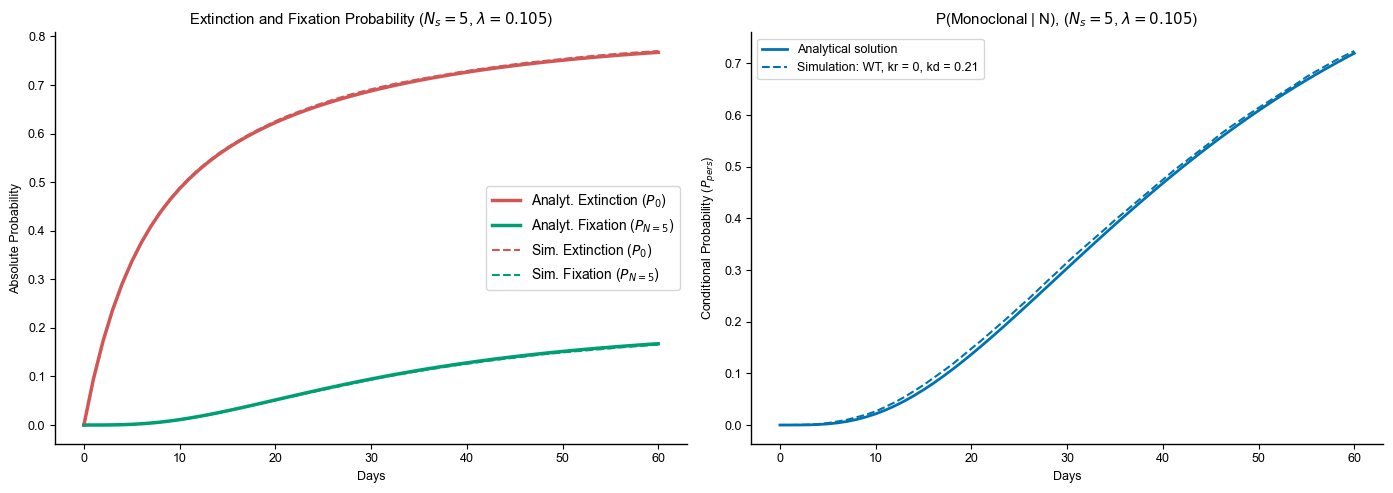

ns_cells = 5
replacement rate = 0.105
--- Probabilities at t = 60 ---
Extinction P0(t) : 0.77 vs. simulation: 0.77
Saturation PNs(t): 0.17 vs. simulation: 0.17 



In [17]:
# ==========================================
# PARAMETERS & SIMULATION TIME
# ==========================================
run_name = "WT, kr = 0, kd = 0.21"
ns_cells = 5
replacement_rate = 0.105
time_point = 60
time_vector = np.linspace(0, time_point, time_point + 1) # continuous time vector

# Run the vectorized calculation
p_n, p0_t, pns_t, p_pers_t = analytical.compute_clone_distribution(
    ns_cells, replacement_rate, time_vector)

# ==========================================
# PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Both panels have to be passed; only one of them is the current axes. The font
# is set in the first cell, as it has to be in place before the figure is built.
setup_plot_style(font_size=9, axes=(ax1, ax2))

# Plot 1: Boundary State Kinetics (Absolute Probabilities)
# Day 0 up to and including `time_point`, so that the simulated curves end where
# the analytical ones do.
days_sim = np.arange(time_point + 1)
extinction, fixation_prob = simulated_extinction_and_fixation(run_name)
ax1.plot(time_vector, p0_t, label=r'Analyt. Extinction ($P_0$)', color=PAPER_RED, lw=2.5)
ax1.plot(time_vector, pns_t, label=f'Analyt. Fixation ($P_{{N={ns_cells}}}$)', color= COLORS[2], lw=2.5)
ax1.plot(days_sim, extinction[:time_point + 1], label=r'Sim. Extinction ($P_0$)', color=PAPER_RED, linestyle="--")
ax1.plot(days_sim, fixation_prob[:time_point + 1], label=f'Sim. Fixation ($P_{{N={ns_cells}}}$)', color= COLORS[2], linestyle="--")
ax1.set_xlabel('Days')
ax1.set_ylabel('Absolute Probability')
ax1.set_title(fr'Extinction and Fixation Probability ($N_s={ns_cells}$, $\lambda = {replacement_rate}$)')
ax1.legend(fontsize=10)

# Plot 2: Experimentally Visible "Persisting" Clone Probabilities
averages_mono = simulated_persisting_probability(run_name)

ax2.plot(time_vector, p_pers_t[ns_cells], label=f'Analytical solution', color=COLORS[0], lw=2)
ax2.plot(days_sim, averages_mono[:time_point + 1], label=f'Simulation: {run_name}', color=COLORS[0], linestyle="--")

ax2.set_xlabel('Days')
ax2.set_ylabel(r'Conditional Probability ($P_{pers}$)')
ax2.set_title(fr'P(Monoclonal | N) ($N_s={ns_cells}$, $\lambda = {replacement_rate}$)')
ax2.legend(loc="upper left")

plt.tight_layout()

if SAVE_FIGURES:
    save_figure("analytical_wt_kr0", FIGURE_DIR)

plt.show()

print(f"ns_cells = {ns_cells}")
print(f"replacement rate = {replacement_rate}")
print(f"--- Probabilities at t = {time_point} ---")
# The index of the simulated curves is the day, so day `time_point` is read at
# `time_point`, not at `time_point + 1`.
print(f"Extinction P0(t) : {p0_t[time_point]:.2f} vs. simulation: {extinction[time_point]:.2f}")
print(f"Saturation PNs(t): {pns_t[time_point]:.2f} vs. simulation: {fixation_prob[time_point]:.2f} \n")

## Figure: symmetric ring, WT parameters

The same comparison for the two wild type runs, against the measured data of the
proximal colon.

replacement rate: 0.16


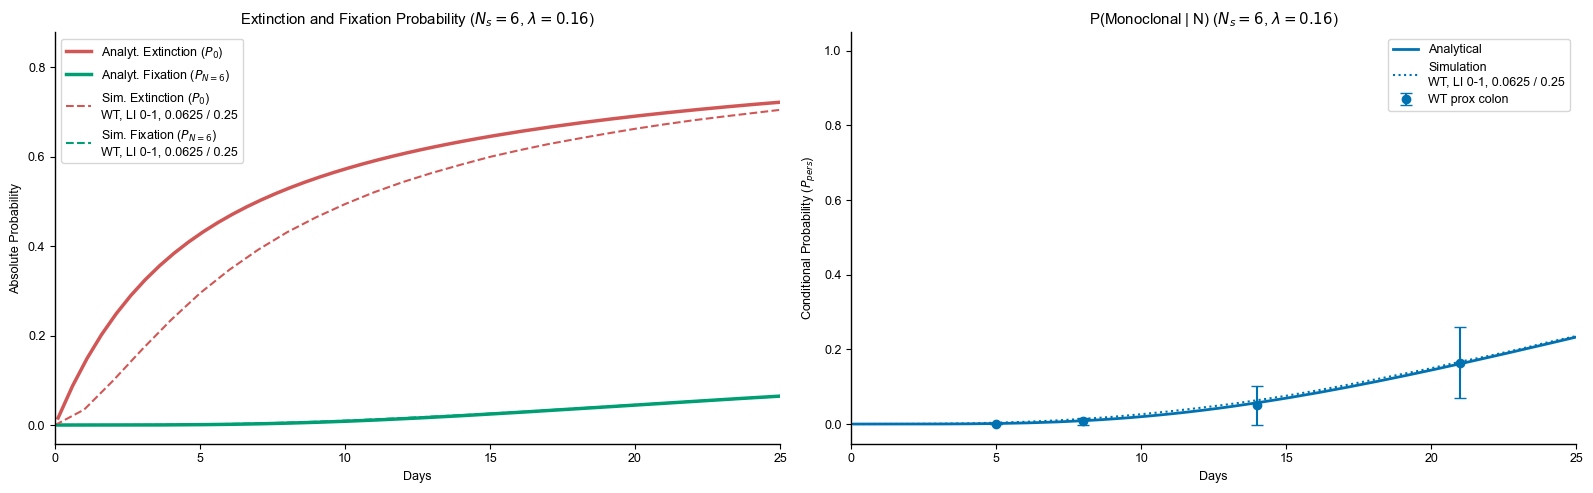

ns_cells = 6
replacement rate = 0.16
--- Probabilities at t = 200 ---
Extinction P0(t) : 0.83 vs. simulation: 0.84
Saturation PNs(t): 0.16 vs. simulation: 0.16 



In [20]:
# ==========================================
# PARAMETERS & SIMULATION TIME
# ==========================================
run_name = "WT, p1 = 0.0525, p2 = 0.21"
run_name_vis_0_1 = "WT, LI 0-1, 0.0625 / 0.25"
ns_cells = 6
replacement_rate = 0.16
time_point = 200
time_vector = np.linspace(0.1, time_point, time_point*2) # continuous time vector

# Run the vectorized calculation
p_n, p0_t, pns_t, p_pers_t = analytical.compute_clone_distribution(
    ns_cells, replacement_rate, time_vector)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
setup_plot_style(font_size=9, axes=(ax1, ax2))
extinction_vis_0_1, fixation_vis_0_1 = simulated_extinction_and_fixation(run_name_vis_0_1)

# Day 0 up to and including `time_point`, so that the simulated curves end where
# the analytical ones do.
days_sim = np.arange(time_point + 1)

# ==========================
# LEFT PANEL
# ==========================
print(f"replacement rate: {replacement_rate}")

ax1.plot(
    time_vector, p0_t,
    label=r'Analyt. Extinction ($P_0$)',
    color=PAPER_RED, lw=2.5
)

ax1.plot(
    time_vector, pns_t,
    label=fr'Analyt. Fixation ($P_{{N={ns_cells}}}$)',
    color=COLORS[2], lw=2.5
)

ax1.plot(
    days_sim, extinction_vis_0_1[:time_point + 1],
    label=fr'Sim. Extinction ($P_0$)' + '\n' + f'{run_name_vis_0_1}',
    color=PAPER_RED, linestyle='--'
)

ax1.plot(
    days_sim, fixation_vis_0_1[:time_point + 1],
    label=fr'Sim. Fixation ($P_{{N={ns_cells}}}$)' + '\n' + f'{run_name_vis_0_1}',
    color=COLORS[2], linestyle='--'
)

ax1.set_xlim(0,25)
ax1.set_xlabel('Days')
ax1.set_ylabel('Absolute Probability')
ax1.set_title(
    fr'Extinction and Fixation Probability ($N_s={ns_cells}$, $\lambda={replacement_rate}$)'
)

ax1.legend()


# ==========================
# RIGHT PANEL
# ==========================
ax2.plot(
    time_vector, p_pers_t[ns_cells],
    label='Analytical',
    color=COLORS[0], lw=2
)

averages_mono = simulated_persisting_probability(run_name_vis_0_1)

ax2.plot(
    days_sim, averages_mono[:time_point + 1],
    label='Simulation\n' + f'{run_name_vis_0_1}',
    color=COLORS[0], linestyle=':'
)
plot_measured(ax2, "block1_WT", COLORS[0], "WT prox colon")

ax2.set_xlim(0,25)
ax2.set_xlabel('Days')
ax2.set_ylabel(r'Conditional Probability ($P_{pers}$)')
ax2.set_title(fr'P(Monoclonal | N) ($N_s={ns_cells}$, $\lambda = {replacement_rate}$)')

ax2.legend()

plt.tight_layout()

if SAVE_FIGURES:
    save_figure("analytical_wt", FIGURE_DIR)
plt.show()

print(f"ns_cells = {ns_cells}")
print(f"replacement rate = {replacement_rate}")
print(f"--- Probabilities at t = {time_point} ---")
print(f"Extinction P0(t) : {p0_t[time_point]:.2f} vs. simulation: {extinction_vis_0_1[time_point]:.2f}")
print(f"Saturation PNs(t): {pns_t[time_point]:.2f} vs. simulation: {fixation_vis_0_1[time_point]:.2f} \n")


## Figure: biased ring, mutant $k_d = 0.5$

The mutant clone is favoured, which the analytical solution describes through
the bias $\delta$ between the two replacement directions.

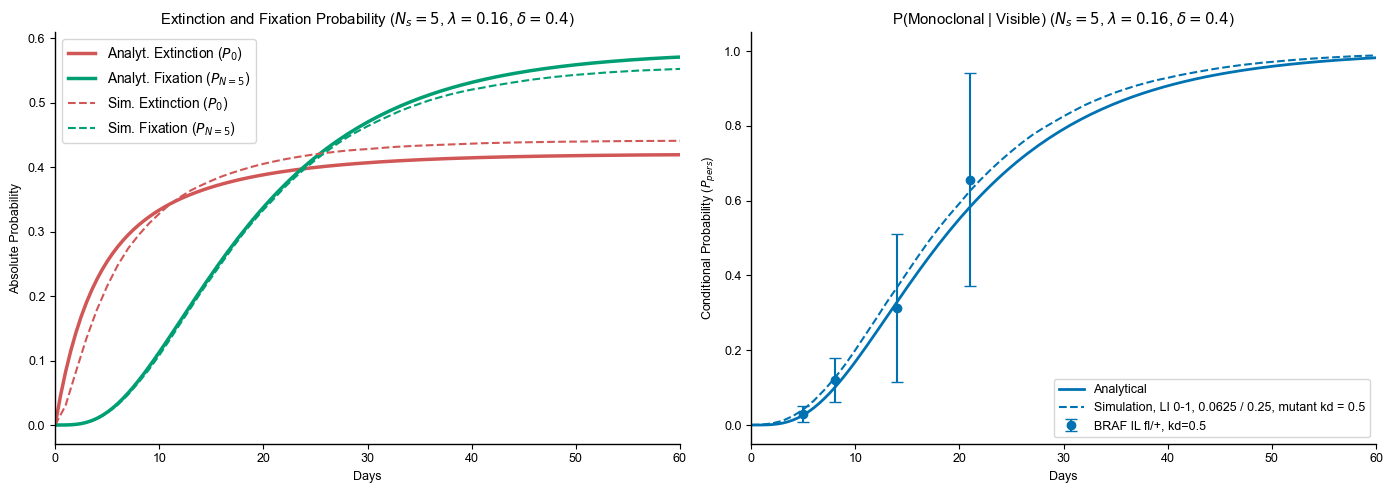

ns_cells = 5, replacement rate = 0.16, delta=0.4
--- Probabilities at t = 150 ---
Extinction P0(t) : 0.42 vs. simulation: 0.44
Saturation PNs(t): 0.58 vs. simulation: 0.56 



In [21]:
# ==========================================
# PARAMETERS & SIMULATION TIME
# ==========================================
run_name = "LI 0-1, 0.0625 / 0.25, mutant kd = 0.5"
ns_cells = 5
replacement_rate = 0.16
time_point = 150
time_vector = np.linspace(0, time_point, time_point*2) # continuous time vector
delta = 0.40

# Run the vectorized calculation
p_n, p0_t, pns_t, p_pers_t = analytical.compute_clone_distribution_asymmetric(
    ns_cells, replacement_rate, delta, time_vector)

# ==========================================
# PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
setup_plot_style(font_size=9, axes=(ax1, ax2))

# Plot 1: Boundary State Kinetics (Absolute Probabilities)
# Day 0 up to and including `time_point`, so that the simulated curves end where
# the analytical ones do.
days_sim = np.arange(time_point + 1)
extinction, fixation_prob = simulated_extinction_and_fixation(run_name)
ax1.plot(time_vector, p0_t, label=r'Analyt. Extinction ($P_0$)', color=PAPER_RED, lw=2.5)
ax1.plot(time_vector, pns_t, label=f'Analyt. Fixation ($P_{{N={ns_cells}}}$)', color= COLORS[2], lw=2.5)
ax1.plot(days_sim, extinction[:time_point + 1], label=r'Sim. Extinction ($P_0$)', color=PAPER_RED, linestyle="--")
ax1.plot(days_sim, fixation_prob[:time_point + 1], label=f'Sim. Fixation ($P_{{N={ns_cells}}}$)', color= COLORS[2], linestyle="--")
ax1.set_xlim(0,60)
ax1.set_xlabel('Days')
ax1.set_ylabel('Absolute Probability')
ax1.set_title(fr'Extinction and Fixation Probability ($N_s={ns_cells}$, $\lambda = {replacement_rate}$, $\delta = {delta}$)')
ax1.legend(fontsize=10)

averages_mono = simulated_persisting_probability(run_name)

ax2.plot(time_vector, p_pers_t[ns_cells], label=f'Analytical', color=COLORS[0], lw=2)
ax2.plot(days_sim, averages_mono[:time_point + 1], label=f'Simulation, {run_name}', color=COLORS[0], linestyle="--")

plot_measured(ax2, "block3_BRAF; IL10RA fl/+", COLORS[0], "BRAF IL fl/+, kd=0.5")
#plot_measured(ax2, "block1_BRAF", COLORS[0], "BRAF prox colon, kd=0.53")

ax2.set_xlim(0,60)
ax2.set_xlabel('Days')
ax2.set_ylabel(r'Conditional Probability ($P_{pers}$)')
ax2.set_title(fr'Persisting Clones($P_n\ /\ (1 - P_0)$, ($N_s={ns_cells}$, $\lambda = {replacement_rate}$, $\delta = {delta}$)')
ax2.set_title(fr'P(Monoclonal | Visible) ($N_s={ns_cells}$, $\lambda = {replacement_rate}$, $\delta = {delta}$)')

ax2.legend()

plt.tight_layout()

if SAVE_FIGURES:
    save_figure("analytical_mutant_kd0_5", FIGURE_DIR)
plt.show()

print(f"ns_cells = {ns_cells}, replacement rate = {replacement_rate}, delta={delta}")
print(f"--- Probabilities at t = {time_point} ---")
print(f"Extinction P0(t) : {p0_t[time_point]:.2f} vs. simulation: {extinction[time_point]:.2f}")
print(f"Saturation PNs(t): {pns_t[time_point]:.2f} vs. simulation: {fixation_prob[time_point]:.2f} \n")


## Figure: biased ring, mutant $k_d = 0.67$

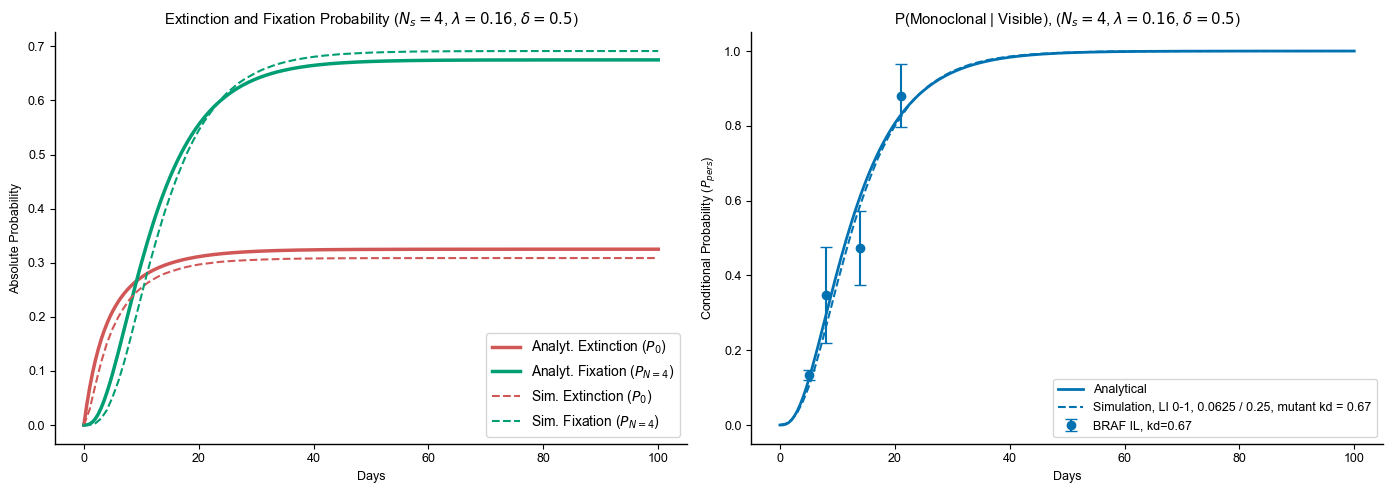

ns_cells = 4, replacement rate = 0.16, delta=0.5
--- Probabilities at t = 100 ---
Extinction P0(t) : 0.32 vs. simulation: 0.31
Saturation PNs(t): 0.67 vs. simulation: 0.69 



In [22]:
# ==========================================
# PARAMETERS & SIMULATION TIME
# ==========================================
run_name = "LI 0-1, 0.0625 / 0.25, mutant kd = 0.67"
ns_cells = 4
replacement_rate = 0.16
time_point = 100
time_vector = np.linspace(0, time_point, time_point*2) # continuous time vector
delta = 0.5

# Run the vectorized calculation
p_n, p0_t, pns_t, p_pers_t = analytical.compute_clone_distribution_asymmetric(
    ns_cells, replacement_rate, delta, time_vector)

# ==========================================
# PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
setup_plot_style(font_size=9, axes=(ax1, ax2))

# Plot 1: Boundary State Kinetics (Absolute Probabilities)
# Day 0 up to and including `time_point`, so that the simulated curves end where
# the analytical ones do.
days_sim = np.arange(time_point + 1)
extinction, fixation_prob = simulated_extinction_and_fixation(run_name)
ax1.plot(time_vector, p0_t, label=r'Analyt. Extinction ($P_0$)', color=PAPER_RED, lw=2.5)
ax1.plot(time_vector, pns_t, label=f'Analyt. Fixation ($P_{{N={ns_cells}}}$)', color= COLORS[2], lw=2.5)
ax1.plot(days_sim, extinction[:time_point + 1], label=r'Sim. Extinction ($P_0$)', color=PAPER_RED, linestyle="--")
ax1.plot(days_sim, fixation_prob[:time_point + 1], label=f'Sim. Fixation ($P_{{N={ns_cells}}}$)', color= COLORS[2], linestyle="--")
ax1.set_xlabel('Days')
ax1.set_ylabel('Absolute Probability')
ax1.set_title(fr'Extinction and Fixation Probability ($N_s={ns_cells}$, $\lambda = {replacement_rate}$, $\delta = {delta}$)')
ax1.legend(fontsize=10)

averages_mono = simulated_persisting_probability(run_name)

ax2.plot(time_vector, p_pers_t[ns_cells], label=f'Analytical', color=COLORS[0], lw=2)
ax2.plot(days_sim, averages_mono[:time_point + 1], label=f'Simulation, {run_name}', color=COLORS[0], linestyle="--")
plot_measured(ax2, "block3_BRAF; IL10RA fl/fl", COLORS[0], "BRAF IL, kd=0.67")

ax2.set_xlabel('Days')
ax2.set_ylabel(r'Conditional Probability ($P_{pers}$)')
ax2.set_title(fr'P(Monoclonal | Visible), ($N_s={ns_cells}$, $\lambda = {replacement_rate}$, $\delta = {delta}$)')
ax2.legend()

plt.tight_layout()

if SAVE_FIGURES:
    save_figure("analytical_mutant_kd0_67", FIGURE_DIR)
plt.show()

print(f"ns_cells = {ns_cells}, replacement rate = {replacement_rate}, delta={delta}")
print(f"--- Probabilities at t = {time_point} ---")
print(f"Extinction P0(t) : {p0_t[time_point]:.2f} vs. simulation: {extinction[time_point]:.2f}")
print(f"Saturation PNs(t): {pns_t[time_point]:.2f} vs. simulation: {fixation_prob[time_point]:.2f} \n")


## Figure: biased ring, mutant $k_d = 0.83$

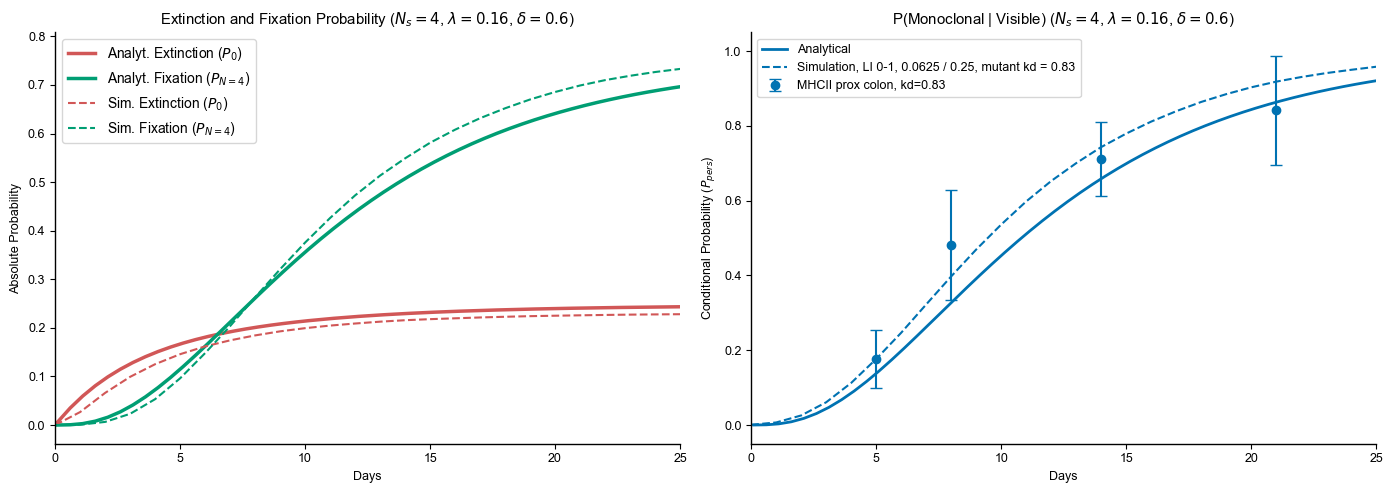

ns_cells = 4, replacement rate = 0.16, delta=0.6
--- Probabilities at t = 100 ---
Extinction P0(t) : 0.25 vs. simulation: 0.23
Saturation PNs(t): 0.75 vs. simulation: 0.77 



In [23]:
# ==========================================
# PARAMETERS & SIMULATION TIME
# ==========================================
run_name = "LI 0-1, 0.0625 / 0.25, mutant kd = 0.83"
ns_cells = 4
replacement_rate = 0.16
time_point = 100
time_vector = np.linspace(0.1, time_point, time_point*2) # continuous time vector
delta = 0.6

# Run the vectorized calculation
p_n, p0_t, pns_t, p_pers_t = analytical.compute_clone_distribution_asymmetric(
    ns_cells, replacement_rate, delta, time_vector)

# ==========================================
# PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
setup_plot_style(font_size=9, axes=(ax1, ax2))

# Plot 1: Boundary State Kinetics (Absolute Probabilities)
# Day 0 up to and including `time_point`, so that the simulated curves end where
# the analytical ones do.
days_sim = np.arange(time_point + 1)
extinction, fixation_prob = simulated_extinction_and_fixation(run_name)
ax1.plot(time_vector, p0_t, label=r'Analyt. Extinction ($P_0$)', color=PAPER_RED, lw=2.5)
ax1.plot(time_vector, pns_t, label=f'Analyt. Fixation ($P_{{N={ns_cells}}}$)', color= COLORS[2], lw=2.5)
ax1.plot(days_sim, extinction[:time_point + 1], label=r'Sim. Extinction ($P_0$)', color=PAPER_RED, linestyle="--")
ax1.plot(days_sim, fixation_prob[:time_point + 1], label=f'Sim. Fixation ($P_{{N={ns_cells}}}$)', color= COLORS[2], linestyle="--")
ax1.set_xlim(0,25)
ax1.set_xlabel('Days')
ax1.set_ylabel('Absolute Probability')
ax1.set_title(fr'Extinction and Fixation Probability ($N_s={ns_cells}$, $\lambda = {replacement_rate}$, $\delta = {delta}$)')
ax1.legend(fontsize=10)

averages_mono = simulated_persisting_probability(run_name)

ax2.plot(time_vector, p_pers_t[ns_cells], label=f'Analytical', color=COLORS[0], lw=2)
ax2.plot(days_sim, averages_mono[:time_point + 1], label=f'Simulation, {run_name}', color=COLORS[0], linestyle="--")
plot_measured(ax2, "block2_BRAF; MHCII fl/fl", COLORS[0], "MHCII prox colon, kd=0.83")

ax2.set_xlim(0,25)
ax2.set_xlabel('Days')
ax2.set_ylabel(r'Conditional Probability ($P_{pers}$)')
ax2.set_title(fr'P(Monoclonal | Visible) ($N_s={ns_cells}$, $\lambda = {replacement_rate}$, $\delta = {delta}$)')
ax2.legend()

plt.tight_layout()

if SAVE_FIGURES:
    save_figure("analytical_mutant_kd0_83", FIGURE_DIR)
plt.show()

print(f"ns_cells = {ns_cells}, replacement rate = {replacement_rate}, delta={delta}")
print(f"--- Probabilities at t = {time_point} ---")
print(f"Extinction P0(t) : {p0_t[time_point]:.2f} vs. simulation: {extinction[time_point]:.2f}")
print(f"Saturation PNs(t): {pns_t[time_point]:.2f} vs. simulation: {fixation_prob[time_point]:.2f} \n")
